# **AI_01_Calories_Burned_Predictor**

## **Data Preprocessing**

### **01. Installing PyTorch with GPU (CUDA) Support**

In [1]:
!pip3 install torch torchvision --extra--index-url https://download.pytorch.org/whl/cu126


[optparse.groups]Usage:[/]   
  pip3 install \[options] <requirement specifier> \[package-index-options] ...
  pip3 install \[options] -r <requirements file> \[package-index-options] ...
  pip3 install \[options] [-e] <vcs project url> ...
  pip3 install \[options] [-e] <local project path> ...
  pip3 install \[options] <archive url/path> ...

no such option: --extra--index-url


In [2]:
import torch
print(torch.cuda.is_available())        # should be True
print(torch.cuda.device_count())        # should be 1
print(torch.cuda.get_device_name(0))    # should show your RTX 5060

True
1
NVIDIA GeForce RTX 5060 Laptop GPU


d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv\lib\site-packages\torch\cuda\__init__.py:384: UserWarning: Found GPU0 NVIDIA GeForce RTX 5060 Laptop GPU which is of compute capability (CC) 12.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 5.0 which supports hardware CC >=5.0,<6.0 except {5.3}
- 6.0 which supports hardware CC >=6.0,<7.0 except {6.2}
- 6.1 which supports hardware CC >=6.1,<7.0 except {6.2}
- 7.0 which supports hardware CC >=7.0,<8.0 except {7.2}
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 13.0, 13.2
  _warn_unsupported_code(d, device_cc, code_ccs)
d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv

### **02. Import the Python Libraries**

##### **Core Libraries**
* *Pandas* - Used to load, organize, clean, and analyze data in tables (DataFrames).
* *NumPy* - Used for fast mathematical calculations and handling missing values.
* *Seaborn* - Used to create attractive statistical charts and graphs.
* *Matplotlib* - Used to create and customize charts, graphs, and plots.

##### Setup Commands
* *%matplotlib inline* - Shows graphs directly inside a Jupyter Notebook
* *sns.set(color_codes=True)* - Applies a better chart style and uses cleaner colors automatically.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
from sklearn.preprocessing import MinMaxScaler

### **03. Load the dataset**

In [4]:
df = pd.read_csv("../datasets/Data_Set.csv")

### **04. Display the first and the last 5 rows of the data**

In [5]:
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74
972,46,Male,88.7,1.63,166,146,66,0.75,542.0,Strength,28.8,3.5,2,1,33.38


### **05. Check for the Types of the Data in the Dataset**

In [6]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object


### **06. Remove the irrelevant columns**

In [7]:
df = df.drop(["Age", "Gender", "Max_BPM", "Avg_BPM", "Resting_BPM", "Fat_Percentage", "BMI"], axis=1)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level
0,88.3,1.71,1.69,1313.0,Yoga,3.5,4,3
1,74.9,1.53,1.30,883.0,HIIT,2.1,4,2
2,68.1,1.66,1.11,677.0,Cardio,2.3,4,2
3,53.2,1.70,0.59,532.0,Strength,2.1,3,1
4,46.1,1.79,0.64,556.0,Strength,2.8,3,1



--- Last 5 Rows ---


,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Workout_Type,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level
968,87.1,1.74,1.57,1364.0,Strength,3.5,4,3
969,66.6,1.61,1.38,1260.0,Strength,3.0,2,1
970,60.4,1.76,1.72,929.0,Cardio,2.7,5,3
971,126.4,1.83,1.10,883.0,HIIT,2.1,3,2
972,88.7,1.63,0.75,542.0,Strength,3.5,2,1


### **07. Check for Duplicate Rows**

In [8]:
rows = df.shape[0]     
columns = df.shape[1]  

print(f"Number of rows = {rows}")
print(f"Number of columns = {columns}")

Number of rows = 973
Number of columns = 8


In [9]:
df.count()

Weight (kg)                      973
Height (m)                       973
Session_Duration (hours)         973
Calories_Burned                  973
Workout_Type                     973
Water_Intake (liters)            973
Workout_Frequency (days/week)    973
Experience_Level                 973
dtype: int64

In [10]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicates rows: ", duplicate_rows_df.shape)

# (duplicates rows, Columns)

Number of duplicates rows:  (0, 8)


### **08. Check missing or Null Values**

In [11]:
print(df.isnull().sum())

Weight (kg)                      0
Height (m)                       0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
dtype: int64


### **09. One-Hot Encoding Encode Catogorical Data**

In [12]:
df = pd.get_dummies(df, columns=["Workout_Type", "Experience_Level"], drop_first=True, dtype=int)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Experience_Level_2,Experience_Level_3
0,88.3,1.71,1.69,1313.0,3.5,4,0,0,1,0,1
1,74.9,1.53,1.30,883.0,2.1,4,1,0,0,1,0
2,68.1,1.66,1.11,677.0,2.3,4,0,0,0,1,0
3,53.2,1.70,0.59,532.0,2.1,3,0,1,0,0,0
4,46.1,1.79,0.64,556.0,2.8,3,0,1,0,0,0



--- Last 5 Rows ---


,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Experience_Level_2,Experience_Level_3
968,87.1,1.74,1.57,1364.0,3.5,4,0,1,0,0,1
969,66.6,1.61,1.38,1260.0,3.0,2,0,1,0,0,0
970,60.4,1.76,1.72,929.0,2.7,5,0,0,0,0,1
971,126.4,1.83,1.10,883.0,2.1,3,1,0,0,1,0
972,88.7,1.63,0.75,542.0,3.5,2,0,1,0,0,0


### **10. Normalize features using MinMaxScaler**

In [13]:
scaler = MinMaxScaler()

scale_cols = ["Weight (kg)", "Height (m)", "Session_Duration (hours)", "Calories_Burned", "Water_Intake (liters)", "Workout_Frequency (days/week)"]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Experience_Level_2,Experience_Level_3
0,0.537264,0.42,0.793333,0.682432,0.909091,0.666667,0,0,1,0,1
1,0.388209,0.06,0.533333,0.391892,0.272727,0.666667,1,0,0,1,0
2,0.312570,0.32,0.406667,0.252703,0.363636,0.666667,0,0,0,1,0
3,0.146830,0.40,0.060000,0.154730,0.272727,0.333333,0,1,0,0,0
4,0.067853,0.58,0.093333,0.170946,0.590909,0.333333,0,1,0,0,0



--- Last 5 Rows ---


,Weight (kg),Height (m),Session_Duration (hours),Calories_Burned,Water_Intake (liters),Workout_Frequency (days/week),Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Experience_Level_2,Experience_Level_3
968,0.523915,0.48,0.713333,0.716892,0.909091,0.666667,0,1,0,0,1
969,0.295884,0.22,0.586667,0.646622,0.681818,0.000000,0,1,0,0,0
970,0.226919,0.52,0.813333,0.422973,0.545455,1.000000,0,0,0,0,1
971,0.961068,0.66,0.400000,0.391892,0.272727,0.333333,1,0,0,1,0
972,0.541713,0.26,0.166667,0.161486,0.909091,0.000000,0,1,0,0,0


## **Tarin Model**

### **11. Split the dataset into Features (X) and Target (y)**

In [14]:
# Inputs (Features)
X = df[['Weight (kg)', 'Height (m)', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Frequency (days/week)', 'Workout_Type_HIIT', 'Workout_Type_Strength', 'Workout_Type_Yoga', 'Experience_Level_2', 'Experience_Level_3']]

# Output (Target)
y = df['Water_Intake (liters)']

### **12. Split the data into Training and Testing sets (Train-Test Split).**

In [15]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 778, Testing samples: 195


### **13. Train and evaluate the Linear Regression model.**

### ***Random Forest Regression***

##### **Mean Squared Error (MSE)**
* *Low value* → Good model, predictions are close to actual values.
* *High value* → Poor model, predictions are far from actual values.

##### **Root Mean Squared Error (RMSE)**
* *Low value* → Good model, small prediction errors.
* *High value* → Poor model, large prediction errors.

##### **R² Score (Accuracy)**
* *Close to 1.00* → Excellent model performance.
* *Around 0.50* → Moderate model performance
* *Close to 0.00 or negative* → Poor model performance.

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Create the model.
model = RandomForestRegressor(
    n_estimators=200,      # Increased the number of trees to 200
    max_depth=8,           # Set the maximum tree depth to 8 to prevent overfitting
    min_samples_split=5, 
    min_samples_leaf=4,
    random_state=42
)

# 2. Train (fit) the model using the training data.
model.fit(X_train, y_train)

# 3. Use the test data to make predictions.
y_pred = model.predict(X_test)

# 4. Evaluate the model's performance.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Accuracy): {r2:.2f}") 

Mean Squared Error (MSE): 0.04
Root Mean Squared Error (RMSE): 0.20
R² Score (Accuracy): 0.47


## **14. Model Evaluation and Visualization**

##### **Graph 1: Actual vs. Predicted Water Intake**

* **Purpose:** Compares actual values with predicted values.
* **Blue Dots:** Show the model's predictions and actual values.
* **Red Dashed Line:** Represents perfect predictions.
* **Interpretation:** Dots closer to the red line mean the model is more accurate.

##### **Graph 2: Feature Importance**

* **Purpose:** Shows which features have the biggest effect on water intake prediction.
* **Bars:** Longer bars indicate more important features.
* **Interpretation:** Helps identify the most influential features and shows that the model makes logical predictions.


C:\Users\Manuka Abeysekara\AppData\Local\Temp\ipykernel_36420\763802189.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[1], palette="viridis")


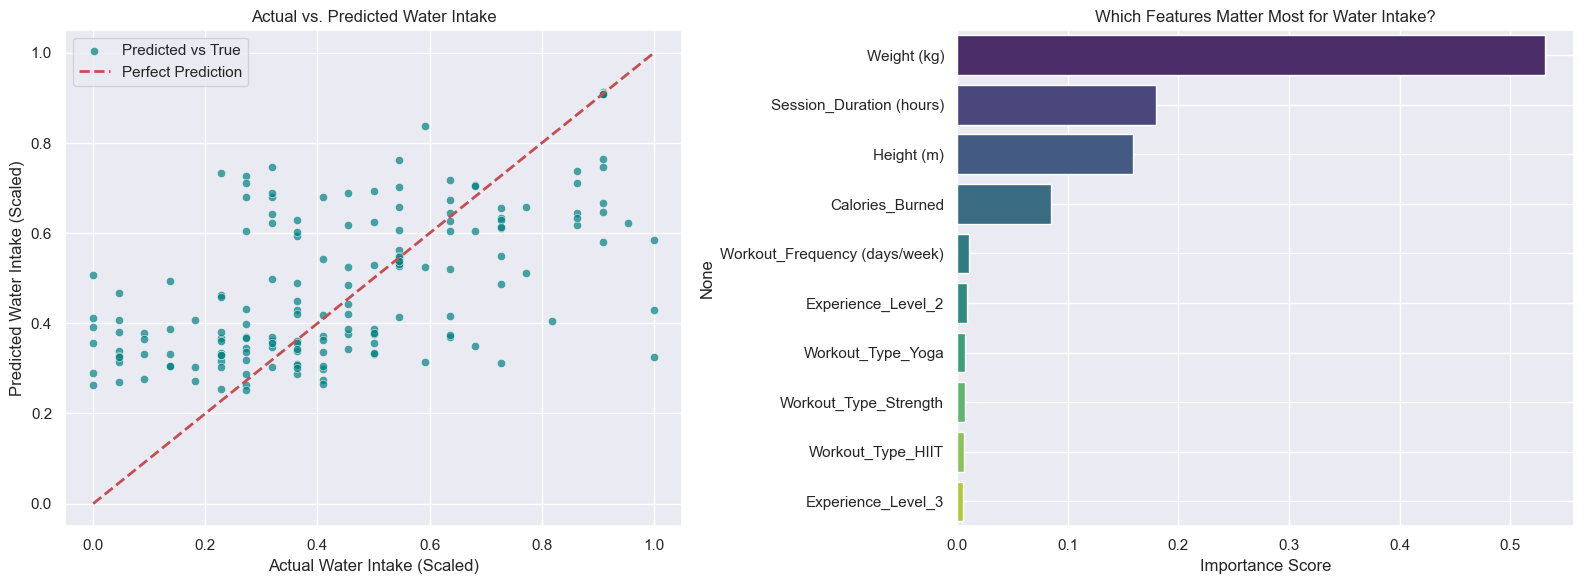

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual vs. Predicted Water Intake 
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color="teal", alpha=0.7, label="Predicted vs True")

# Perfect Prediction Line එක
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Water Intake (Scaled)")
axes[0].set_ylabel("Predicted Water Intake (Scaled)")
axes[0].set_title("Actual vs. Predicted Water Intake")
axes[0].legend()
axes[0].grid(True)

# Graph 2: Random Forest Feature Importance (Finding the Most Important Features)
# Get the feature importance values from the trained model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort features from highest importance to lowest importance
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Draw a bar plot
sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[1], palette="viridis")
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Which Features Matter Most for Water Intake?")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### **15. Test the traine model by giving sample value.**

In [20]:
import numpy as np
import pandas as pd

# 1. Define Sample User Data
sample_user = {
    'Weight (kg)': 70.1,
    'Height (m)': 1.79,
    'Session_Duration (hours)': 1.08,
    'Calories_Burned': 743.0,
    'Workout_Frequency (days/week)': 3.0,
    'Workout_Type_HIIT': 0,
    'Workout_Type_Strength': 0,
    'Workout_Type_Yoga': 0,
    'Experience_Level_2': 1,
    'Experience_Level_3': 0
}

# Convert the dictionary into a Pandas DataFrame
input_df = pd.DataFrame([sample_user], columns=X.columns)

# 2. Create a dummy array with exactly 6 columns for the Scaler
# This follows the exact column order used during training
dummy_array = np.array([[
    input_df['Weight (kg)'].values[0],
    input_df['Height (m)'].values[0],
    input_df['Session_Duration (hours)'].values[0],
    input_df['Calories_Burned'].values[0],           
    0,                                                # <- Temporary 0 for Water Intake
    input_df['Workout_Frequency (days/week)'].values[0]
]])

# Scale the dummy array using the trained MinMaxScaler
scaled_dummy = scaler.transform(dummy_array)

# Copy the original DataFrame and replace numeric values with scaled values
input_df_scaled = input_df.copy()
input_df_scaled['Weight (kg)'] = scaled_dummy[0, 0]
input_df_scaled['Height (m)'] = scaled_dummy[0, 1]
input_df_scaled['Session_Duration (hours)'] = scaled_dummy[0, 2]
input_df_scaled['Calories_Burned'] = scaled_dummy[0, 3]                  
input_df_scaled['Workout_Frequency (days/week)'] = scaled_dummy[0, 5]


# 3. Get the model prediction
scaled_prediction = model.predict(input_df_scaled)


# 4. Convert the scaled prediction back to original Liters (Inverse Transform)
# Place the scaled prediction into the Water Intake position (Index 4)
scaled_dummy[0, 4] = scaled_prediction[0]

# Inverse transform to get the actual water intake value
final_prediction = scaler.inverse_transform(scaled_dummy)[0, 4]


# 5. Display the final result
print("="*50)
print(f"👉 Predicted Daily Water Intake: {final_prediction:.2f} Liters")
print("="*50)


👉 Predicted Daily Water Intake: 2.21 Liters


d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## **16. Export the Model**

In [32]:
import joblib
import os

# Save path
output_dir = r"D:/My_Projects/Project_02_GYM_Mobile_App/AI_Models/saved_models"
os.makedirs(output_dir, exist_ok=True)

# 1. Save the trained Random Forest model
joblib.dump(model, os.path.join(output_dir, 'AI_02_Water_Intake_Model.joblib'))

# 2. Save the MinMaxScaler
joblib.dump(scaler, os.path.join(output_dir, 'AI_02_Water_Intake_Scaler.joblib'))

print(f"✅ Model and Scaler successfully exported to: {output_dir}")

✅ Model and Scaler successfully exported to: D:/My_Projects/Project_02_GYM_Mobile_App/AI_Models/saved_models
